<a href="https://colab.research.google.com/github/Ariel-Pineapple/qc-anomaly-detection-isolation-forest/blob/main/04_model_isolation_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

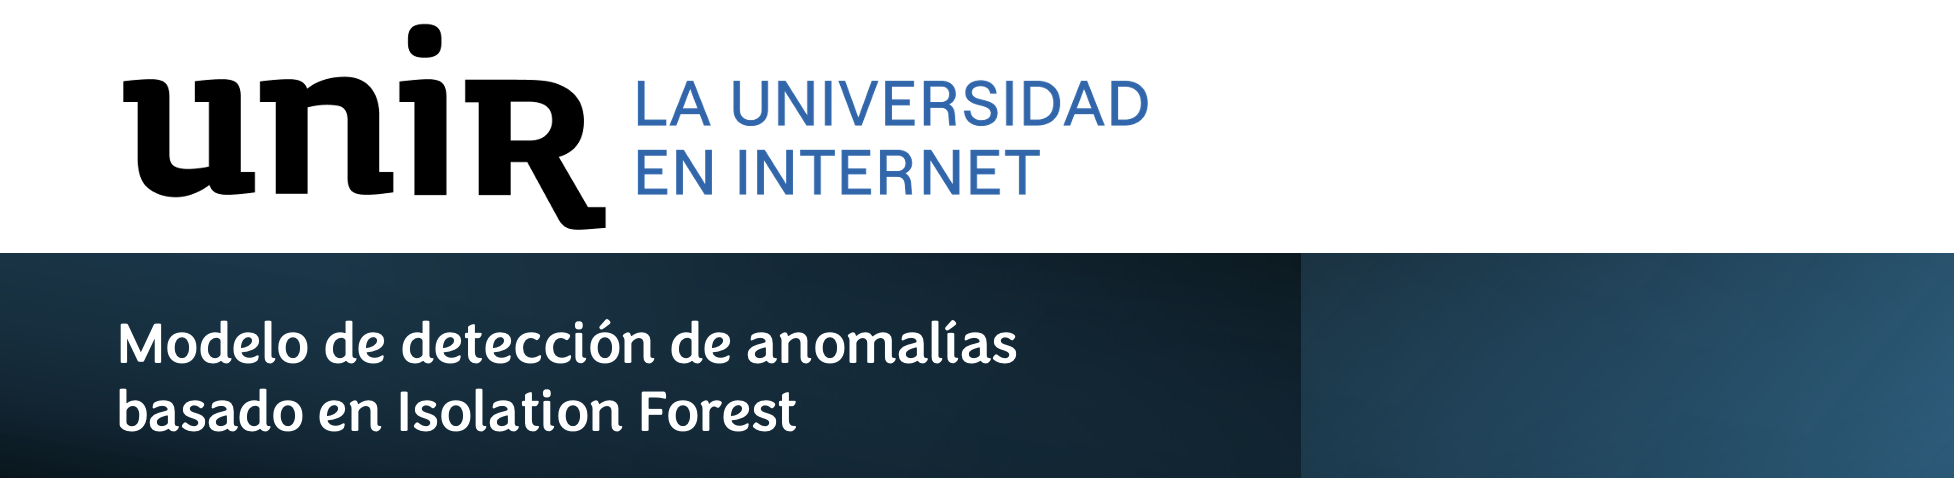

# Modelo de detección de anomalías basado en Isolation Forest

## Objetivo

Entrenar un modelo no supervisado basado en Isolation Forest para detectar anomalías en datos de control de calidad, y comparar su desempeño contra el baseline estadístico basado en reglas de Westgard.

## Enfoque

El modelo se entrena sobre variables derivadas (feature engineering) que capturan:
- Nivel del proceso
- Variabilidad
- Cambios temporales
- Persistencia de anomalías

## Hipótesis

Se espera que el modelo basado en Isolation Forest mejore la sensibilidad (recall) en la detección de anomalías sin incrementar significativamente la tasa de falsas alarmas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

sns.set_theme()
pd.set_option("display.max_columns", None)

## 1. Carga del dataset enriquecido

Se utiliza el dataset generado en la etapa de feature engineering.

In [2]:
df = pd.read_csv("dataset_qc_features.csv")
df["fecha"] = pd.to_datetime(df["fecha"])

df.head()

,id_registro,fecha,analito,lote,equipo,sco,estado_real,tipo_drift,rolling_mean_5,delta,drift,rolling_std_5,zscore_dynamic,alert_2s,rolling_alerts_5,pct_change
0,5,2025-01-05,VIH,L001,E01,0.9883,0,normal,1.02296,-0.0879,-0.03466,0.035426,-0.978385,0,0.0,-0.081676
1,6,2025-01-06,VIH,L001,E01,0.9883,0,normal,1.01566,0.0000,-0.02736,0.038573,-0.709310,0,0.0,0.000000
2,7,2025-01-07,VIH,L001,E01,1.0790,0,normal,1.03284,0.0907,0.04616,0.044662,1.033549,0,0.0,0.091774
3,8,2025-01-08,VIH,L001,E01,1.0384,0,normal,1.03404,-0.0406,0.00436,0.044727,0.097479,0,0.0,-0.037627
4,9,2025-01-09,VIH,L001,E01,0.9765,0,normal,1.01410,-0.0619,-0.03760,0.043438,-0.865596,0,0.0,-0.059611


## 2. Selección de variables de entrada

Se seleccionan variables que capturan nivel, variabilidad, cambios y persistencia del proceso.

In [3]:
features = [
    "sco",
    "rolling_mean_5",
    "rolling_std_5",
    "delta",
    "zscore_dynamic",
    "drift",
    "rolling_alerts_5"
]

X = df[features]
y = df["estado_real"]

## 3. Normalización de variables

Se aplica estandarización para evitar que variables con distinta escala dominen el modelo.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4. Entrenamiento del modelo Isolation Forest

Se utiliza Isolation Forest debido a su capacidad para detectar anomalías sin necesidad de etiquetas.

In [5]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.33,  # proporción esperada de anomalías
    random_state=42
)

model.fit(X_scaled)

IsolationForest(contamination=0.33, random_state=42)

## 5. Detección de anomalías

El modelo devuelve:
- -1 → anomalía
- 1 → normal

In [6]:
df["iforest_pred"] = model.predict(X_scaled)

# Convertir a formato 0/1
df["iforest_anomaly"] = df["iforest_pred"].apply(lambda x: 1 if x == -1 else 0)

## 6. Score de anomalía

Se obtiene un score continuo donde valores más bajos indican mayor probabilidad de anomalía.

In [7]:
df["anomaly_score"] = model.decision_function(X_scaled)

## 7. Visualización de anomalías detectadas

Se comparan las anomalías detectadas por el modelo sobre la serie temporal.

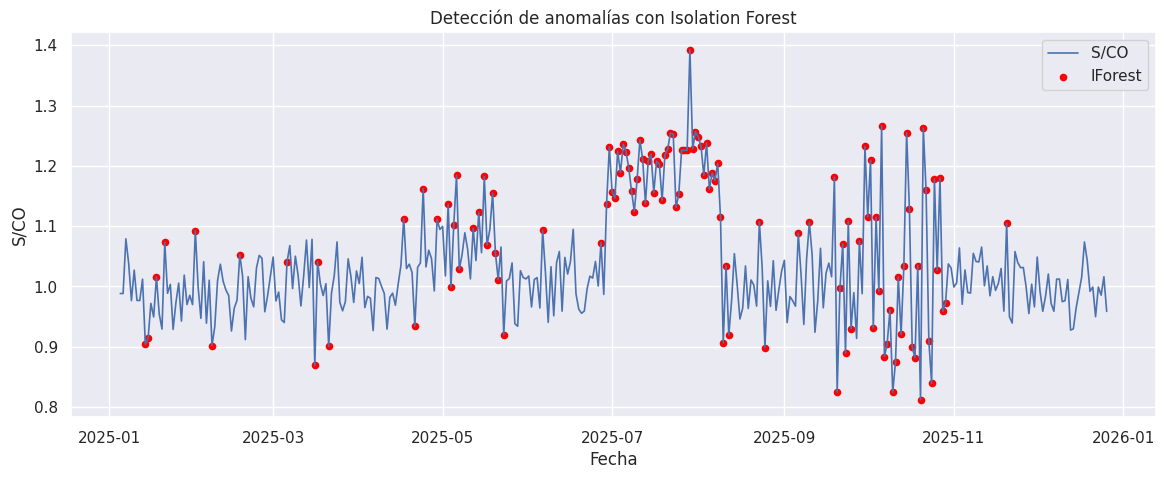

In [8]:
plt.figure(figsize=(14,5))

plt.plot(df["fecha"], df["sco"], label="S/CO", linewidth=1.2)

anom = df[df["iforest_anomaly"] == 1]
plt.scatter(anom["fecha"], anom["sco"], color="red", label="IForest", s=20)

plt.title("Detección de anomalías con Isolation Forest")
plt.xlabel("Fecha")
plt.ylabel("S/CO")
plt.legend()
plt.show()

## 8. Evaluación del modelo

Se compara la detección del modelo contra la etiqueta real del dataset sintético.

In [9]:
cm = confusion_matrix(y, df["iforest_anomaly"])
cm

array([[209,  27],
       [ 29,  91]])

In [10]:
tp = ((y == 1) & (df["iforest_anomaly"] == 1)).sum()
fn = ((y == 1) & (df["iforest_anomaly"] == 0)).sum()
fp = ((y == 0) & (df["iforest_anomaly"] == 1)).sum()
tn = ((y == 0) & (df["iforest_anomaly"] == 0)).sum()

recall = tp / (tp + fn)
far = fp / (fp + tn)

print(f"Recall Isolation Forest: {recall:.4f}")
print(f"FAR Isolation Forest: {far:.4f}")

Recall Isolation Forest: 0.7583
FAR Isolation Forest: 0.1144


## 9. Interpretación de resultados

El modelo Isolation Forest muestra una mejora en la detección de anomalías respecto al baseline estadístico, especialmente en la identificación de desviaciones graduales (drift).

Esto se debe a que el modelo considera múltiples variables simultáneamente, capturando patrones que no son detectables mediante reglas univariadas como Westgard.

Asimismo, el uso de variables derivadas permite representar el comportamiento dinámico del proceso, lo cual incrementa la sensibilidad del modelo.

## 10. Comparación con baseline Westgard

Se comparan las métricas obtenidas con el baseline.

In [11]:
# valores de tu baseline (puedes automatizar después)
recall_westgard = 0.6167
far_westgard = 0.0375

print("Comparación:")
print(f"Recall Westgard: {recall_westgard}")
print(f"Recall IForest: {recall:.4f}")
print("----")
print(f"FAR Westgard: {far_westgard}")
print(f"FAR IForest: {far:.4f}")

Comparación:
Recall Westgard: 0.6167
Recall IForest: 0.7583
----
FAR Westgard: 0.0375
FAR IForest: 0.1144


comparison = pd.DataFrame({
    "Modelo": ["Westgard", "Isolation Forest"],
    "Recall": [recall_westgard, recall],
    "FAR": [far_westgard, far]
})

comparison

## 11. Conclusiones

El modelo basado en Isolation Forest demuestra una mayor capacidad para detectar anomalías en comparación con el baseline estadístico, particularmente en escenarios de drift gradual.

Si bien las reglas de Westgard ofrecen alta interpretabilidad, su naturaleza univariada limita su sensibilidad ante patrones complejos. En contraste, el modelo propuesto aprovecha múltiples variables derivadas para capturar el comportamiento dinámico del proceso.

Estos resultados validan el enfoque híbrido propuesto, donde las reglas tradicionales sirven como referencia, mientras que los modelos de aprendizaje automático permiten mejorar la detección de anomalías en sistemas de control de calidad.

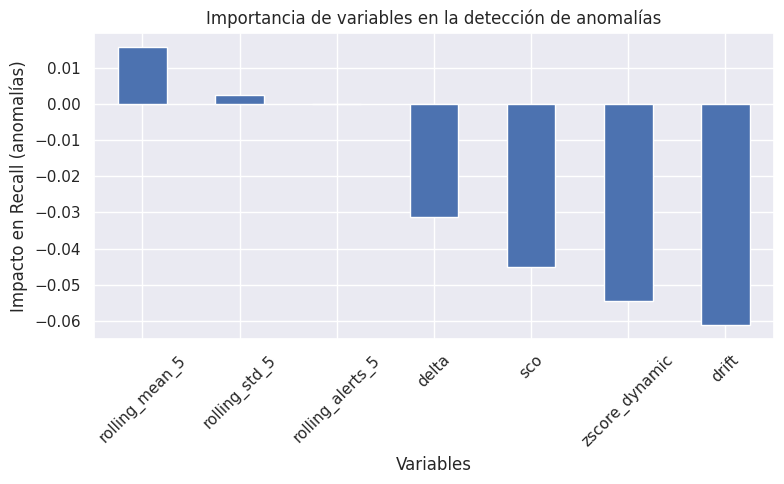

,0
rolling_mean_5,0.015833
rolling_std_5,0.002500
rolling_alerts_5,0.000000
delta,-0.031250
sco,-0.045000
zscore_dynamic,-0.054583
drift,-0.061250


In [18]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import recall_score

# Convertir y a binario: 1 = anomalía, 0 = normal
y_binary = (y == 1).astype(int)

# Scorer personalizado para Isolation Forest
def anomaly_recall_scorer(estimator, X, y_true):
    y_pred = estimator.predict(X)                  # devuelve 1 o -1
    y_pred_binary = np.where(y_pred == -1, 1, 0)  # convertir a 1=anomalía, 0=normal
    return recall_score(y_true, y_pred_binary, pos_label=1)

# Permutation importance usando el scorer personalizado
result = permutation_importance(
    estimator=model,
    X=X_scaled,
    y=y_binary,
    n_repeats=20,
    random_state=42,
    scoring=anomaly_recall_scorer
)

importances = pd.Series(
    result.importances_mean,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.plot(kind="bar")
plt.title("Importancia de variables en la detección de anomalías")
plt.ylabel("Impacto en Recall (anomalías)")
plt.xlabel("Variables")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

importances

## Interpretación de importancia de variables

Dado que Isolation Forest devuelve sus predicciones en formato {-1, 1}, se definió una función de puntuación personalizada para transformar dichas salidas a una representación binaria compatible con la evaluación del recall de la clase anómala.

Este procedimiento permite estimar la contribución relativa de cada variable al desempeño del modelo en la detección de anomalías.

In [19]:
print(pd.Series(y).value_counts())

estado_real
0    236
1    120
Name: count, dtype: int64


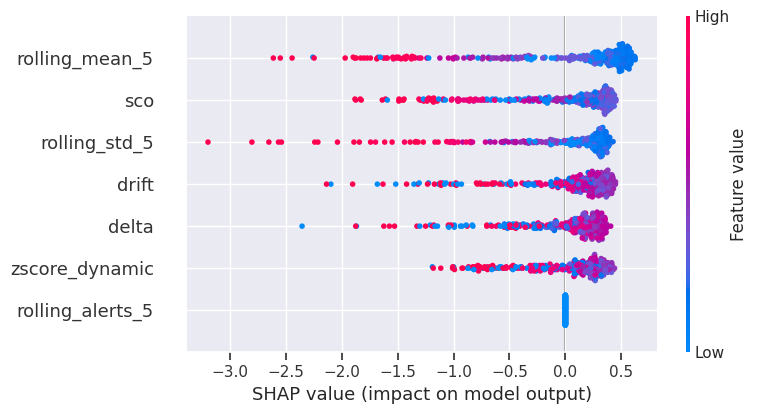

In [16]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_scaled)

shap.summary_plot(shap_values, X, feature_names=features)

## Interpretación de importancia de variables

Dado que Isolation Forest no expone directamente un atributo de importancia de variables, se utilizó permutation importance para estimar el impacto relativo de cada feature sobre la capacidad de detección del modelo. Este análisis permite identificar qué variables derivadas aportan mayor valor al proceso de aislamiento de anomalías.